# Module 4 – LSTM (Insurance Review Sentiment Analysis)

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Insurance Reviews Dataset

In [3]:
import pandas as pd

df = pd.read_csv(r"D:\InsureAI\data\reviews\Final Data.csv")

df.head()

,Unnamed: 0,Customer Name,Customer Location,Review Text
0,0,Sarah Hoelscher,US,Easy to use and understand! Qu...
1,1,Bruce Winslow,CR,It was a real pleasure to spea...
2,2,Kelly Wilmeth,US,Byron Preston was super helpfu...
3,3,Stephanie LeBlanc,US,Byron Preston was amazing walk...
4,4,JPD,US,"Thanks Josh, top rate service ..."


## Dataset Information

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Dataset Shape: (44934, 5)

Columns:
Index(['Unnamed: 0', 'Customer Name', 'Customer Location', 'Review Text',
       'Clean_Review'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44934 entries, 0 to 44933
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         44934 non-null  int64 
 1   Customer Name      44934 non-null  object
 2   Customer Location  44934 non-null  object
 3   Review Text        44934 non-null  object
 4   Clean_Review       44934 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


## Check Missing Values

In [6]:
print(df.isnull().sum())

Unnamed: 0           0
Customer Name        0
Customer Location    0
Review Text          0
Clean_Review         0
dtype: int64


## Select Review Text Column

In [7]:
df = df[['Review Text']]

df.head()

,Review Text
0,Easy to use and understand! Qu...
1,It was a real pleasure to spea...
2,Byron Preston was super helpfu...
3,Byron Preston was amazing walk...
4,"Thanks Josh, top rate service ..."


## Download VADER Lexicon

In [8]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Farshana\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Import VADER Sentiment Analyzer

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

print("VADER Loaded Successfully!")

VADER Loaded Successfully!


## Create Sentiment Labels

In [10]:
def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Review Text"].apply(get_sentiment)

df.head()

,Review Text,Sentiment
0,Easy to use and understand! Qu...,Positive
1,It was a real pleasure to spea...,Positive
2,Byron Preston was super helpfu...,Positive
3,Byron Preston was amazing walk...,Positive
4,"Thanks Josh, top rate service ...",Positive


## Check Sentiment Distribution

In [11]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    39726
Negative     2693
Neutral      2515
Name: count, dtype: int64


## Encode Sentiment Labels

In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Sentiment"] = label_encoder.fit_transform(df["Sentiment"])

print("Label Mapping:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

df.head()

Label Mapping:
{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


,Review Text,Sentiment
0,Easy to use and understand! Qu...,2
1,It was a real pleasure to spea...,2
2,Byron Preston was super helpfu...,2
3,Byron Preston was amazing walk...,2
4,"Thanks Josh, top rate service ...",2


## Clean Review Text

In [13]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["Clean_Review"] = df["Review Text"].apply(clean_text)

df.head()

,Review Text,Sentiment,Clean_Review
0,Easy to use and understand! Qu...,2,easy to use and understand quick results and a...
1,It was a real pleasure to spea...,2,it was a real pleasure to speak with victoria ...
2,Byron Preston was super helpfu...,2,byron preston was super helpful in explaining ...
3,Byron Preston was amazing walk...,2,byron preston was amazing walking me through e...
4,"Thanks Josh, top rate service ...",2,thanks josh top rate service


## Tokenize Review Text

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_length = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Clean_Review"])

sequences = tokenizer.texts_to_sequences(df["Clean_Review"])

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Vocabulary Size:", len(tokenizer.word_index))
print("Padded Shape:", padded_sequences.shape)

Vocabulary Size: 23469
Padded Shape: (44934, 100)


## Prepare Features and Labels

In [21]:
X = padded_sequences
y = df["Sentiment"]

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (44934, 100)
Label Shape: (44934,)


## Split Training and Testing Data

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (35947, 100)
Testing Shape: (8987, 100)


## Build LSTM Model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

print("LSTM Model Created Successfully!")

d:\InsureAI\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM Model Created Successfully!


## Compile LSTM Model

In [24]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("LSTM Model Compiled Successfully!")

LSTM Model Compiled Successfully!


In [25]:
model.build(input_shape=(None, 100))

## View Model Summary

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,035 (5.42 MB)

 Trainable params: 1,420,035 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

## Train LSTM Model

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 116s 127ms/step - accuracy: 0.8833 - loss: 0.4507 - val_accuracy: 0.8848 - val_loss: 0.4380
Epoch 2/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 58s 64ms/step - accuracy: 0.8837 - loss: 0.4411 - val_accuracy: 0.8851 - val_loss: 0.4346
Epoch 3/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.8863 - loss: 0.4358 - val_accuracy: 0.8841 - val_loss: 0.4325
Epoch 4/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 68s 76ms/step - accuracy: 0.8893 - loss: 0.3583 - val_accuracy: 0.8987 - val_loss: 0.2505
Epoch 5/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.9355 - loss: 0.1835 - val_accuracy: 0.9442 - val_loss: 0.1607
Epoch 6/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 137s 152ms/step - accuracy: 0.9645 - loss: 0.1142 - val_accuracy: 0.9506 - val_loss: 0.1704
Epoch 7/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 73s 82ms/step - accuracy: 0.9756 - loss: 0.0834 - val_accuracy: 0.9513 - val_loss: 0.1612
Epoch 8/15
899/899 ━━━━━━━━━━━━━━━━━━━━ 129s 143ms/step - accuracy: 0.9826 - loss: 0.0

## Evaluate LSTM Model

In [27]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.9443 - loss: 0.1727
Test Loss: 0.1727
Test Accuracy: 0.9443


## Predict Test Data

In [28]:
import numpy as np

# Predict probabilities
y_pred = model.predict(X_test)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

print("Predictions generated successfully!")

281/281 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step
Predictions generated successfully!


## Classification Report

In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.76      0.53      0.62       539
           1       0.84      0.72      0.77       503
           2       0.96      0.99      0.97      7945

    accuracy                           0.94      8987
   macro avg       0.85      0.74      0.79      8987
weighted avg       0.94      0.94      0.94      8987



## Confusion Matrix

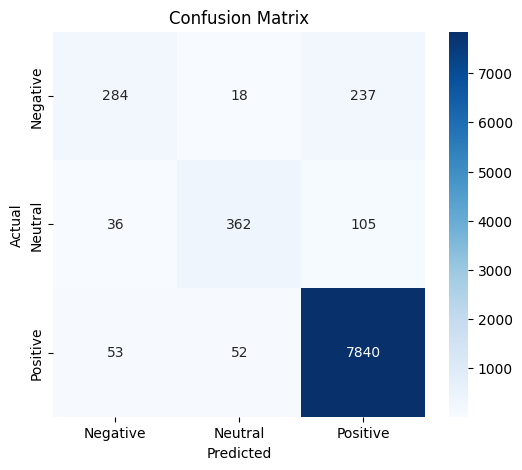

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Neutral","Positive"],
    yticklabels=["Negative","Neutral","Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Training Accuracy and Loss Graphs

In [31]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

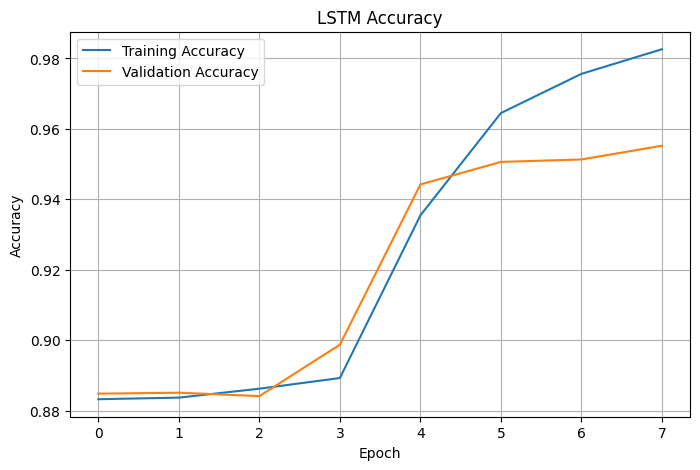

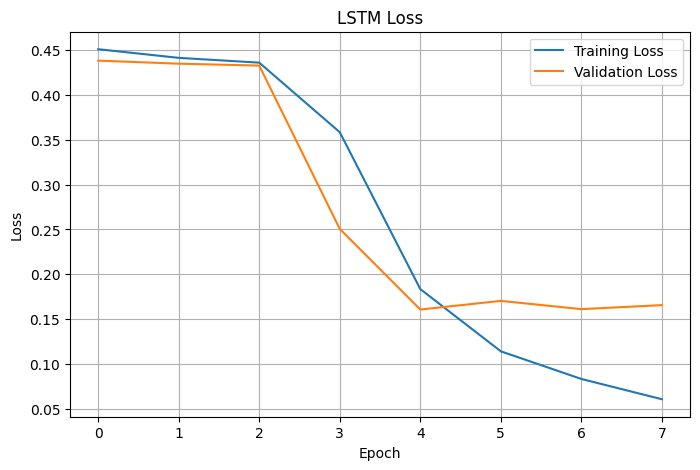

In [32]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Save the model 

In [34]:
import os
print(os.getcwd())

d:\InsureAI\notebooks


In [35]:
model.save("../models/lstm_sentiment_model.keras")
print("✅ Model Saved Successfully!")

✅ Model Saved Successfully!


In [15]:
import pickle

with open("../models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Tokenizer Saved Successfully!")

✅ Tokenizer Saved Successfully!


## Testing the LSTM Model with Custom Reviews

In [36]:
sample_reviews = [
    "My claim was settled very fast.",
    "The insurance company rejected my claim.",
    "Excellent customer service and quick response.",
    "The claim process was very slow and disappointing.",
    "I am happy with the insurance service."
]

In [37]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

clean_reviews = [clean_text(review) for review in sample_reviews]

In [38]:
sample_sequences = tokenizer.texts_to_sequences(clean_reviews)

sample_padded = pad_sequences(
    sample_sequences,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [39]:
predictions = model.predict(sample_padded)

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive" if pred[0] >= 0.5 else "Negative"

    print("Review:", review)
    print("Prediction Score:", round(float(pred[0]), 4))
    print("Predicted Sentiment:", sentiment)
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Review: My claim was settled very fast.
Prediction Score: 0.0394
Predicted Sentiment: Negative
------------------------------------------------------------
Review: The insurance company rejected my claim.
Prediction Score: 0.0551
Predicted Sentiment: Negative
------------------------------------------------------------
Review: Excellent customer service and quick response.
Prediction Score: 0.0013
Predicted Sentiment: Negative
------------------------------------------------------------
Review: The claim process was very slow and disappointing.
Prediction Score: 0.2269
Predicted Sentiment: Negative
------------------------------------------------------------
Review: I am happy with the insurance service.
Prediction Score: 0.0027
Predicted Sentiment: Negative
------------------------------------------------------------
